#Note, code formatting + graphing + style (ex: section 1 headers, equation stylisitc formatting in writeups) done by AI as mentioned in lecture on tuesday. 

# Final Project 2
## By: Maxwell Stephen, Branden Weir, and Mahan Akhavanzadeh
### EIDs: ms94532, bjw3366, ma73262


# Section 1: Introduction & System Selection: 

The chosen stiff section for this part was Part D. The reason for this is that it most closely paralleled our group's choice for part one, where we modelled the assignment on a spring system for the Concorde (Modeled label in Part 1). So following the procedure in this same vein, we decided to follow-up with another spring-esque system in keeping up with the theme of our project. 

The chosen system model is Option D: Mechanical System with High Damping. This models a spring-mass system. The equation given models the system with the given constants of a spring extremely resistant to motion. This has the applicaiton of shock absorbers, vibration dampers, and seismic isolation. This could apply for example to the same scenario in Part 1, with the landing gear of a plane, which would act as both shock absorber and a vibration damper. Though in our analysis, the Concorde's exact specs (again mentioned in Part 1), would not be nearly as resistant as the specs of that given for this assignment. 

The variables given are the following: 

- **x**: indicates disceplacent of the center of mass which is measured in meters
- **t**: indicates time in seconds
- **dx/dt**: indicates derivative of displacement over time, AKA velocity in meters/second
- **k**: spring constant
- **c**: damping coefficient, the force which opposes the motion of the object
- **k/c**: damping rate, this serves as the lambda value for the equations. This is what simulates stiffness in equations. 
- **F(t)**: this represents the external force applied to the mass. 

Values: 

- x(0) = 1 m
- k/c = 5000 s
- F(t) = 10sin(t)
- t from 0 to 2pi seconds (one full sinsoidal rotation).

## Governing ODEs

The given equation for Part D is: 

$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$$

After plugging in the values mentioned above, the equation becomes:

$$\frac{dx}{dt} = -5000x + 0.002\sin(t)$$

This is equivalent to the generalized ODE form:

$$\frac{dy}{dt} = -\lambda y + g(t)$$

with λ = 5000 and g(t) = 0.002sin(t).


# Section 2: Demonstration of Stiffness

Below, our group attempted to utilize Euler's Forward however as expected it was unsuccessful. This can be clearly seen as the function leads to ever increasing magnitudes which never converge. The numerical solution here is thus unstable.

The calculated stiffness ratio was found to be inadequate for the purposes of Euler's Forward, and thus it became clear that Explicit Methods, such as Euler's Forward, were overall inadequate for our purposes. The step-size, being pre-determined to be .1, did not yield useable results. 

Thus it could be seen that Implicit Methods are necessary for the purposes of this project. 

The step count required for Explicit is simply too large as it was found to be 15707 steps for the calculation. This is far too great and inefficient for the purpose of the program. 

The fast time scale was found to be 2.00e-04s, and the slow time scale was found to be 1.00 seconds. The stiffness ratio utilized and found was 5000, and the maximum stable step size was found to be .0004. All of this information in tandem leads to the conclusion that implicit is the only other viable alternative, since the explicit has led to nowhere.

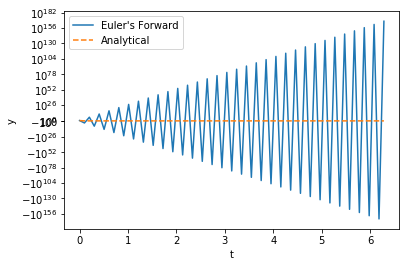

Fast time scale: 2.00e-04 s
Slow time scale: 1.00e+00 s
Stiffness ratio: 5000.0
The maximum stable step size is: 0.0004
The requried number of steps as a result of this step size is : 15707 steps


In [108]:
# ============================================================
# SECTION 2: DEMONSTRATION OF STIFFNESS
# ============================================================
#AI utilized in regards to placement of constant, furthermore for application of np.pi for domain. 
## Part 2 - Euler's forward  
import matplotlib.pyplot as plt
import numpy as np

h = 0.1
t_start, t_end = 0, 2*np.pi
num_steps = int((t_end - t_start) / h)
t_values = np.linspace(t_start, t_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)
y_values[0] = 1

def f(t, x):
    return -5000*x + .002*np.sin(t)

for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])

trigConstant = 5000**2 + 1 
b = (.002 *5000) / (trigConstant)
d = (-.002) / (trigConstant)
c = (1 - d)

y_analytical = c*np.exp(-5000*t_values) + b*np.sin(t_values) + d*np.cos(t_values)

plt.plot(t_values, y_values, label="Euler's Forward")
plt.plot(t_values, y_analytical, label="Analytical", linestyle='--')
plt.xlabel('t')
plt.ylabel('y')
plt.yscale('symlog')
plt.legend()
plt.show()


# ------------------------------------------------------------
# Stiffness Ratio
# ------------------------------------------------------------

lambdaVal = 5000 
sinComponent = 1 

timeScale1 = 1 / lambdaVal   #This time indicates the quickes amount of time the calculations can occur   
timeScale2 = 1 / sinComponent #This value indicates the slowest amount of time the calculations can occur

stiffness_ratio = timeScale2 / timeScale1

print(f"Fast time scale: {timeScale1:.2e} s") ##AI utilzied for formatting 
print(f"Slow time scale: {timeScale2:.2e} s")
print(f"Stiffness ratio: {stiffness_ratio}")


# ------------------------------------------------------------
# Impracticality of Explicit Methods
# ------------------------------------------------------------

stableH = 2 / lambdaVal   # via Forward Euler 
steps = int((t_end - t_start) / stableH) #calculates number of steps 

print("The maximum stable step size is: " + str(stableH))
print("The requried number of steps as a result of this step size is : " + str(steps) + " steps")



# Section 3: Mathematical Setup

The Euler's Backward Method utilized is adapted from the recent challenge which uses an Adaptive Backward Method. We have adapted the Adaptive Backward Method to be retrofitted into a standard Euler's Backward Method.

**Base form of Euler's Backward:**

$$y_{n+1} = y_n + h \cdot f(t_{n+1}, y_{n+1})$$

We plugged in the above mentioned values in Section 1 to yield in our code:

**Our specific f(t, x):**

$$f(t, x) = -5000x + 0.002\sin(t)$$

However, firstly we establish in this part the functions for Newton-Raphson, and also for Backward Euler. We use the given linear form as described:

**General linear stiff ODE form:**

$$\frac{dy}{dt} = -\lambda y + g(t)$$

The Newton-Raphson utilizes the Residual Function which measures how accurate the guess is.

**Residual function (general):**

$$g(y_{n+1}) = y_{n+1} - y_n - h \cdot f(t_{n+1}, y_{n+1}) = 0$$

**Residual function for our problem:**

$$g(x_{n+1}) = x_{n+1} - x_n - h \cdot [-5000 \cdot x_{n+1} + 0.002\sin(t_{n+1})]$$

Furthermore, we need to derivative the residual of x(n+1), because x(n+1) is the unknown being solved for.

**Derivative of residual (general):**

$$g'(x_{n+1}) = 1 - h \cdot \frac{\partial f}{\partial x}$$

Plugging in known values yields, g' has only one dependency which is h: there for it is calculated once for every step.

**Derivative of residual for our problem:**

$$g'(x_{n+1}) = 1 + 5000h$$

The final formula ends up being,

**Newton-Raphson update formula for our problem:**

$$x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{g(x_{n+1}^{(k)})}{g'(x_{n+1}^{(k)})}$$

In [109]:
# ============================================================
# SECTION 3: MATHEMATICAL SETUP & SECTION 4: IMPLEMENTATION
# ============================================================
#AI utilized in order to help retrofit Backward Euler for Challenge to new application. 
##formula from notes 
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=20):
    y_next = y  # Initial guess
    iteration = 0 
    for _ in range(max_iter):
        iteration += 1
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(g_val) < tol:
            return y_new, iteration  # Converged
        y_next = y_new
    print(f"Warning: max iterations exceeded at t={t}")
    return y_next, iteration


# Backward Euler with fixed step
def backward_euler_fixed(f, y0, t0, tf, h_init, tol=1e-6, max_iter=20):
    t_values = [t0]
    y_values = [y0]
    iterationNum = []
    h = h_init
    t = t0
    y = y0
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        y, iteration = backward_euler_step(f, y, t, h, tol, max_iter)
        t += h
        t_values.append(t)
        y_values.append(y)
        iterationNum.append(iteration)
    return np.array(t_values), np.array(y_values), np.array(iterationNum)


def f(t, x): 
    return -5000*x + .002*np.sin(t) ##From Part 2 

def fprime(x):
    derivativeFunc = -5000
    return derivativeFunc 


# Section 5: Results & Analysis 

Backward Euler was applied through four different "h" values, that being 1.0, .5, .1, and .01. Through this calculation it was determined that the Newton-Raphson iterations reach the solution in 1 to 2 iterations in every step-size. This shows the accuracy of the Newton-Raphson through all four "h" values converging along the graph. The solution comparison plot follows a sinusoidal curve showing x(t) from 0 to 2pi, showing the displacement of the center of mass over time.

This is in contrast with the forward Euler, which forever increased without convergence, while the backward Euler was stable between the different "h" values.

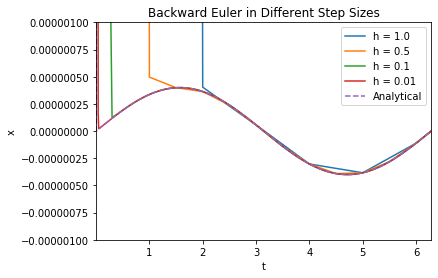

Average iterations: 1.0079491255961843


In [110]:

# ============================================================
# SECTION 5: RESULTS & ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 5a: Solution Comparison Across Step Sizes
# ------------------------------------------------------------

yInitialVal = y_values[0]  #Initial condition from earlier
step_sizes = [1.0, 0.5, 0.1, 0.01]  #Different step sizes to test

#Run backwards Euler for each step size and plot
for i in step_sizes:
    T_BackEul, X_BackEul, iterations = backward_euler_fixed(f, yInitialVal, t_start, t_end, i)
    plt.plot(T_BackEul, X_BackEul, label="h = " + str(i))

#Plot analytical solution for comparison
t_fine = np.linspace(t_start, t_end, 1000) ##AI utilzied here for cause of confusion over np.linspace, and ordering.
x_analytical = c*np.exp(-5000*t_fine) + b*np.sin(t_fine) + d*np.cos(t_fine)
plt.plot(t_fine, x_analytical, '--', label="Analytical") 

plt.xlabel('t')
plt.ylabel('x')
plt.title("Backward Euler in Different Step Sizes")
plt.legend()
plt.xlim(0.005, t_end)
plt.ylim(-1e-6, 1e-6)  ##AI used to make plot, and readable 
plt.show()

##The data shows that Backwards Euler is stable for all Step Sizes 

print("Average iterations: " + str(iterations.mean()))


# Section 6: Performance & Analysis

Below the code there is a table comparing the outputs of Forward and Backward Euler. 

The computational cost required through the following results clearly show that the Backward Euler is more efficient than the Forward Euler. Below it can be seen that the number of Function Evaluations for the Forward Euler was 15707, however the best out of the "h" values for the Backward Euler was only 14, far below that of Forward Euler.

The smaller the "h" values, the smaller the errors. h = .01 reached errors nearing 10^-15. This demonstrates extreme accuracy. However, for the larger "h" values such as 1.0, the error started large however plateaued to be ~10^-11. The smaller the "h" value then the more computational work must be done to achieve the results, however the bigger the "h" value, the less computational work needs to be done although to achieve results less accurate.

In practice, I would recommend using the least accurate of the Backward Eulers, that being h=1.0. The reason for this is that not only does it take less computing power, but also the changes in measured distance is so finite that it would not make a meaningful impact in the real-world as the distance is so small that it is a matter of .00004 millimeters. Although it may be the "least" accurate of the "h" values for Backward Euler, it is still extremely accurate relative to the Forward Euler. It takes far fewer steps than the next alternative.

## Step Size Stability Comparison

For Forward Euler, by utilizing the applied equations, it is found that h < 0.0004 s.

For Backward Euler, via the same method, it is found that it will always be stable because it will always converge eventually on an answer. The below table generated with AI shows that, in contrast with the Forward Euler, the Backward Euler is unconditionally stable.

| Method          | Max Stable Step Size       | Steps for t ∈ [0, 2π]  |
|-----------------|----------------------------|------------------------|
| Forward Euler   | 4 × 10⁻⁴ s                 | 15,707                 |
| Backward Euler  | ∞ (unconditionally stable) | As few as 7 (h = 1.0)  |

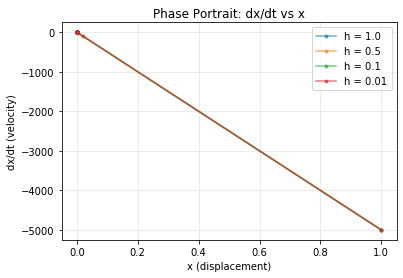

In [116]:
##Phase portrait, AI utilied for understanding of Phase Portrait and implementation. 

for i in step_sizes:
    timeVals, xVals, iterations = backward_euler_fixed(f, yInitialVal, t_start, t_end, i)
    
    # Compute dx/dt at each point using the ODE: dx/dt = -5000x + 0.002*sin(t)
    dxdt = -5000 * xVals + 0.002 * np.sin(timeVals)
    
    plt.plot(xVals, dxdt, 'o-', label="h = " + str(i), markersize=3, alpha=0.6)

plt.xlabel('x (displacement)')
plt.ylabel('dx/dt (velocity)')
plt.title('Phase Portrait: dx/dt vs x')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Forward Euler:
  Step size: 0.0004
  Total steps: 15707
  Function evaluations: 15707
Backward Euler (h = 1.0):
# steps: 7
Average iterations: 2.0
Function Evaluations: 14

Backward Euler (h = 0.5):
# steps: 13
Average iterations: 2.0
Function Evaluations: 26

Backward Euler (h = 0.1):
# steps: 63
Average iterations: 1.97
Function Evaluations: 124

Backward Euler (h = 0.01):
# steps: 629
Average iterations: 1.01
Function Evaluations: 634

Method              h         Steps     Avg NR    Func Evals  
--------------------------------------------------------------
Forward Euler       0.0004    15707     N/A       15707       
Backward Euler      1.0       7         2.0       14          
Backward Euler      0.5       13        2.0       26          
Backward Euler      0.1       63        1.97      124         
Backward Euler      0.01      629       1.01      634         


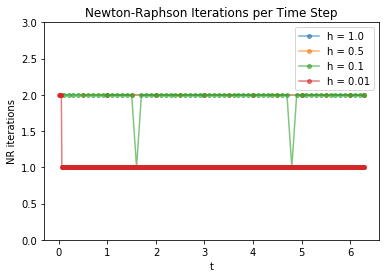

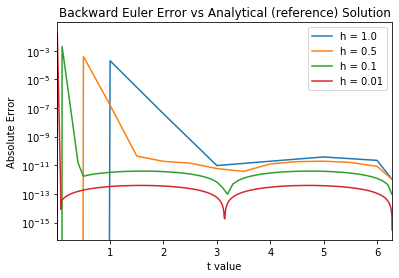

In [112]:


# ============================================================
# SECTION 6: PERFORMANCE ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 6a: Computational Cost Comparison
# ------------------------------------------------------------

#Forward Euler
print("Forward Euler:")
print("  Step size: " + str(stableH))
print("  Total steps: " + str(steps))
print("  Function evaluations: " + str(steps))

#Backward Euler with different "h" values 
for i in step_sizes:
    T_BE, X_BE, iterations = backward_euler_fixed(f, yInitialVal, t_start, t_end, i)
    total_steps = len(T_BE) - 1
    print("Backward Euler (h = " + str(i) + "):")
    print("# steps: " + str(total_steps))
    print("Average iterations: " + str(round(iterations.mean(), 2)))
    print("Function Evaluations: " + str(iterations.sum()))
    print("")


#There is a similar step count for all of the backwardsEulers. This further shows that it is demonstrably true that not only that the Forward Euler is not effective for this problem. As the function result was extremely unstable with an inefficient total number of steps. However, with the Backward Euler, it is not only stable but accurate between iterations.

#AI utilized to make a nicely-formatted table here:
print(f"{'Method':<20}{'h':<10}{'Steps':<10}{'Avg NR':<10}{'Func Evals':<12}")
print("-" * 62)
print(f"{'Forward Euler':<20}{0.0004:<10}{15707:<10}{'N/A':<10}{15707:<12}")
for h_val in step_sizes:
    T_BE, X_BE, iters = backward_euler_fixed(f, yInitialVal, t_start, t_end, h_val)
    print(f"{'Backward Euler':<20}{h_val:<10}{len(T_BE)-1:<10}{round(iters.mean(),2):<10}{int(iters.sum()):<12}")

# ------------------------------------------------------------
# 6b: Convergence Behavior - NR Iterations Per Step
# ------------------------------------------------------------

#Plot: NR iterations per step
for i in step_sizes:
    T_BE, X_BE, iterations = backward_euler_fixed(f, yInitialVal, t_start, t_end, i)
    plt.plot(T_BE[1:], iterations, 'o-', label="h = " + str(i), markersize=4, alpha=0.6)   #AI Utilized for graphing w/ transperency  
plt.xlabel('t')
plt.ylabel('NR iterations')
plt.title('Newton-Raphson Iterations per Time Step')
plt.legend()
plt.ylim(0, 3)
plt.show()


# ------------------------------------------------------------
# 6c: Solution Quality - Error vs Analytical
# ------------------------------------------------------------

for i in step_sizes:
    timeVals, xVals, iterations = backward_euler_fixed(f, yInitialVal, t_start, t_end, i)
    
    #Variables defined in first coding block 
    xAnalytical = c*np.exp(-5000*timeVals) + b*np.sin(timeVals) + d*np.cos(timeVals)
    
    error = abs(xVals - xAnalytical)
    
    plt.plot(timeVals, error, label="h = " + str(i))
plt.xlabel("t value")
plt.ylabel("Absolute Error")
plt.title('Backward Euler Error vs Analytical (reference) Solution')
plt.legend()
plt.yscale('log')  ##AI used to make plot + refination for readability 
plt.xlim(0.01, t_end)  
plt.show()
#The plot shows that the larger the t value, over time the error decreases.

# Section 7: Conclusions

The findings above have indicated that the Forward Euler is ineffective and unusable for the purposes of doing computations for the Mechanical System with High Damping. As shown through error comparison, Newton-Raphson, and measurements in step-sizes, the Backward Eulers are far more accurate. The most accurate of these, although it requires the smallest step size, is "h" = .01. Although it is most accurate, the other "h" values are still quite accurate, and the difference does not make a meaningful impact in the real world, making the recommended choice of h = 1 sufficient for the real world calculation. The application of this for example could be utilized for the landing gear of a plane, where the displacement difference between h = 1 and h = .1 is so small that the distance would be completely negligible. 

Furthermore, it is determined that Explicit should be utilized when the equation is non-stiff. The reason we used Implicit here was because the equation was in fact stiff, because (as in the section 2), the results of the initial graphs led to that conclusion due to lack of convergence.

The greatest challenges that took place for this section was doing the wrong section, for example going through and solving the entirety through the same Backward Euler as in the recent challenge. This greatly complicated the work because prior iterations had to be retroactively fixed with the standard Backward Euler, instead of the Adaptive Backward Euler. 

The lessons learned then are to properly read the instructions prior to beginning the assignment rather than prior to turning it in. It could have saved a lot of time of work.